In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, make_scorer
import warnings
warnings.filterwarnings('ignore')

# set display options
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

In [2]:
df = pd.read_csv("/kaggle/input/datasets/nalisha/smartphone-usage-and-addiction-analysis-dataset/Smartphone_Usage_And_Addiction_Analysis_7500_Rows (1).csv")

print(f"original shape: {df.shape}")
df.info()

original shape: (7500, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 1

In [14]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


In [3]:
# drop unnecessary columns
df = df.drop(columns=["transaction_id", "user_id"])
print(f"shape after dropping columns: {df.shape}")
print(f"\ncolumns: {df.columns.tolist()}")

shape after dropping columns: (7500, 14)

columns: ['age', 'gender', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact', 'addiction_level', 'addicted_label']


missing values summary:
                 missing_count  missing_pct
addiction_level            819        10.92


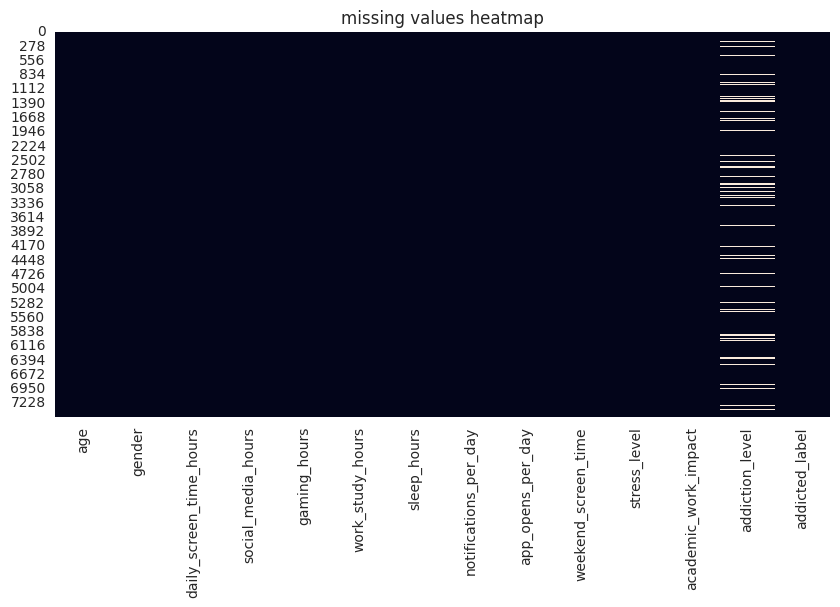


duplicate rows: 0


In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df)) * 100
missing_table = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_with_values = missing_table[missing_table["missing_count"] > 0]
print("missing values summary:")
print(missing_with_values)

# visualize missing values
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("missing values heatmap")
plt.show()

print(f"\nduplicate rows: {df.duplicated().sum()}")

addicted label distribution:
addicted_label
1    0.707733
0    0.292267
Name: proportion, dtype: float64


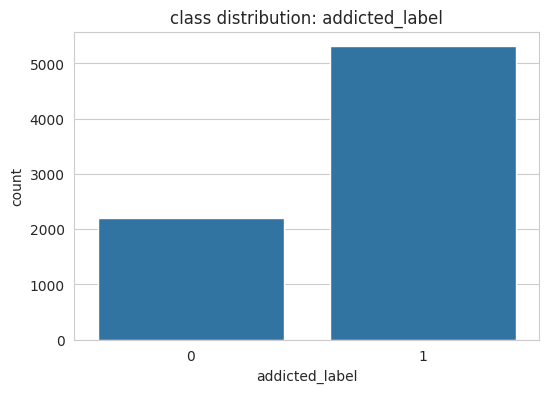


addiction level distribution:
addiction_level
Moderate    2874
Severe      2434
Mild        1373
NaN          819
Name: count, dtype: int64

missing in addiction_level: 10.92%


In [5]:
target_dist = df["addicted_label"].value_counts(normalize=True)
print("addicted label distribution:")
print(target_dist)

# plot class distribution
plt.figure(figsize=(6,4))
sns.countplot(x="addicted_label", data=df)
plt.title("class distribution: addicted_label")
plt.show()

addiction_level_counts = df["addiction_level"].value_counts(dropna=False)
print("\naddiction level distribution:")
print(addiction_level_counts)
print(f"\nmissing in addiction_level: {df['addiction_level'].isnull().mean() * 100:.2f}%")

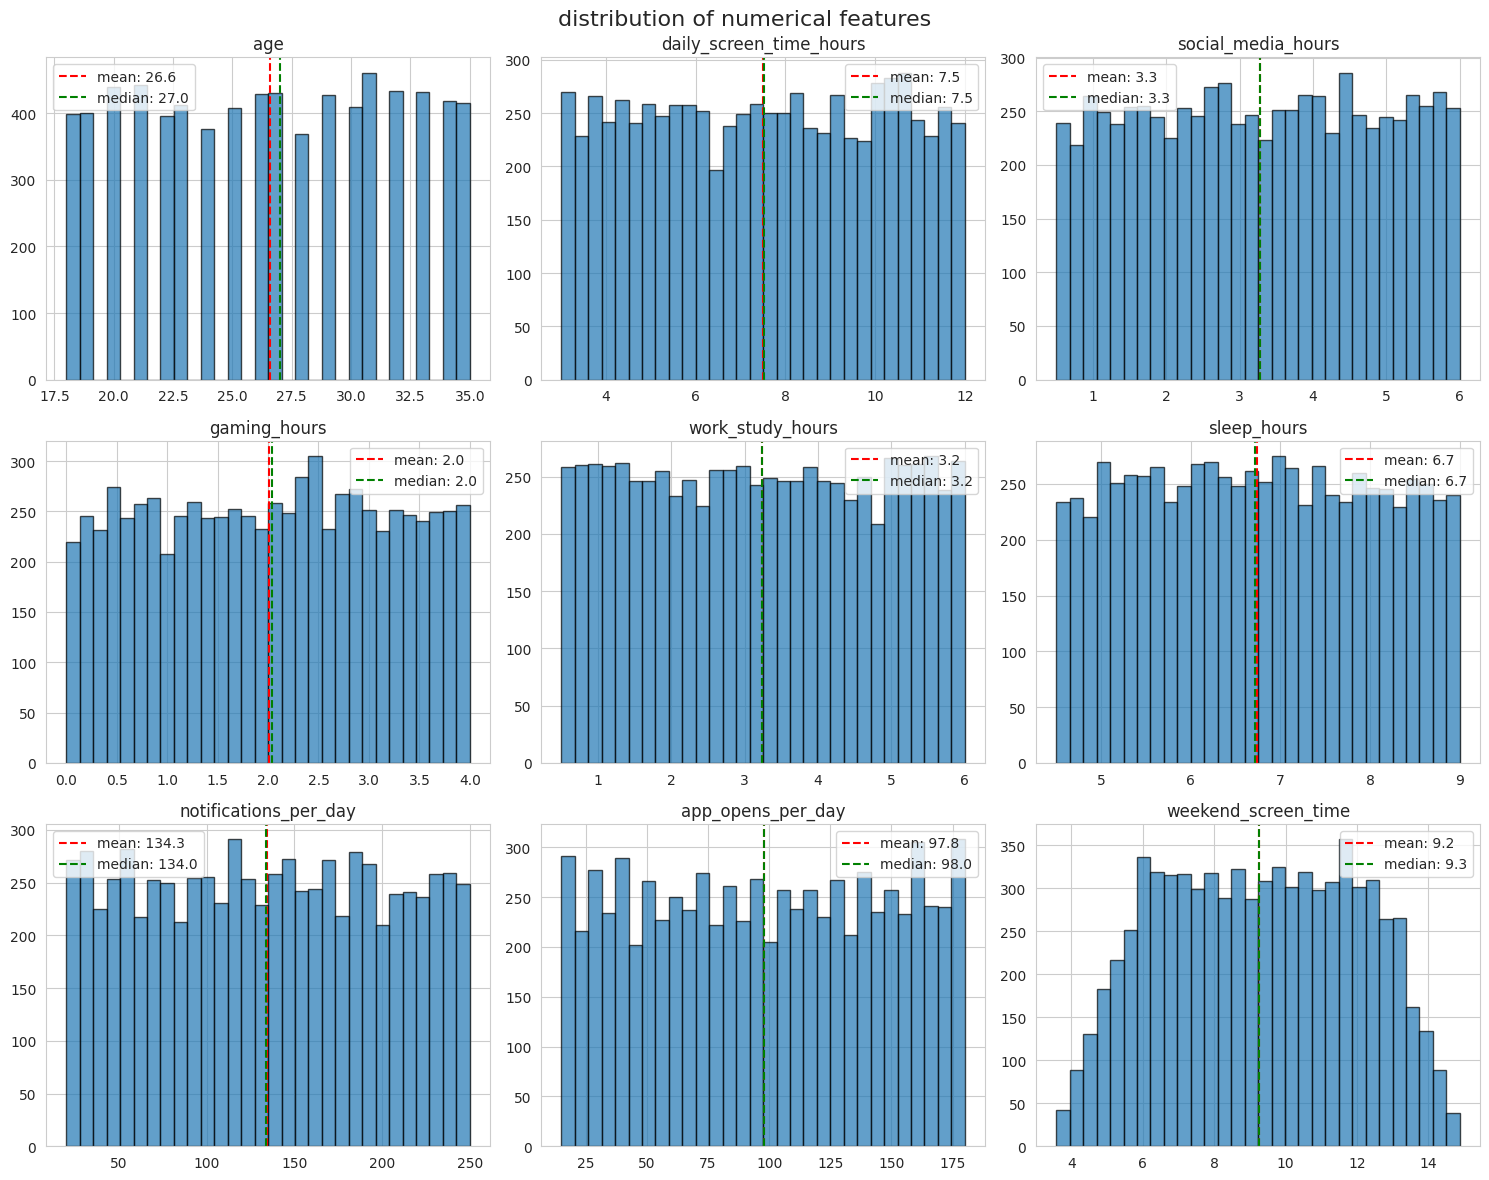

In [6]:
num_cols = ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 
            'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 
            'weekend_screen_time']

# plot histograms
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(num_cols):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].axvline(df[col].mean(), color='red', linestyle='dashed', label=f'mean: {df[col].mean():.1f}')
    axes[idx].axvline(df[col].median(), color='green', linestyle='dashed', label=f'median: {df[col].median():.1f}')
    axes[idx].set_title(f'{col}')
    axes[idx].legend()
plt.suptitle('distribution of numerical features', fontsize=16)
plt.tight_layout()
plt.show()

In [7]:
print("iqr outliers detection")

outlier_summary = []
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_pct = (len(outliers) / len(df)) * 100
    outlier_summary.append({
        'feature': col,
        'outliers_count': len(outliers),
        'outliers_pct': f'{outlier_pct:.1f}%',
        'lower_bound': f'{lower_bound:.2f}',
        'upper_bound': f'{upper_bound:.2f}'
    })
    print(f"{col}: {len(outliers)} outliers ({outlier_pct:.1f}%)")

iqr outliers detection
age: 0 outliers (0.0%)
daily_screen_time_hours: 0 outliers (0.0%)
social_media_hours: 0 outliers (0.0%)
gaming_hours: 0 outliers (0.0%)
work_study_hours: 0 outliers (0.0%)
sleep_hours: 0 outliers (0.0%)
notifications_per_day: 0 outliers (0.0%)
app_opens_per_day: 0 outliers (0.0%)
weekend_screen_time: 0 outliers (0.0%)


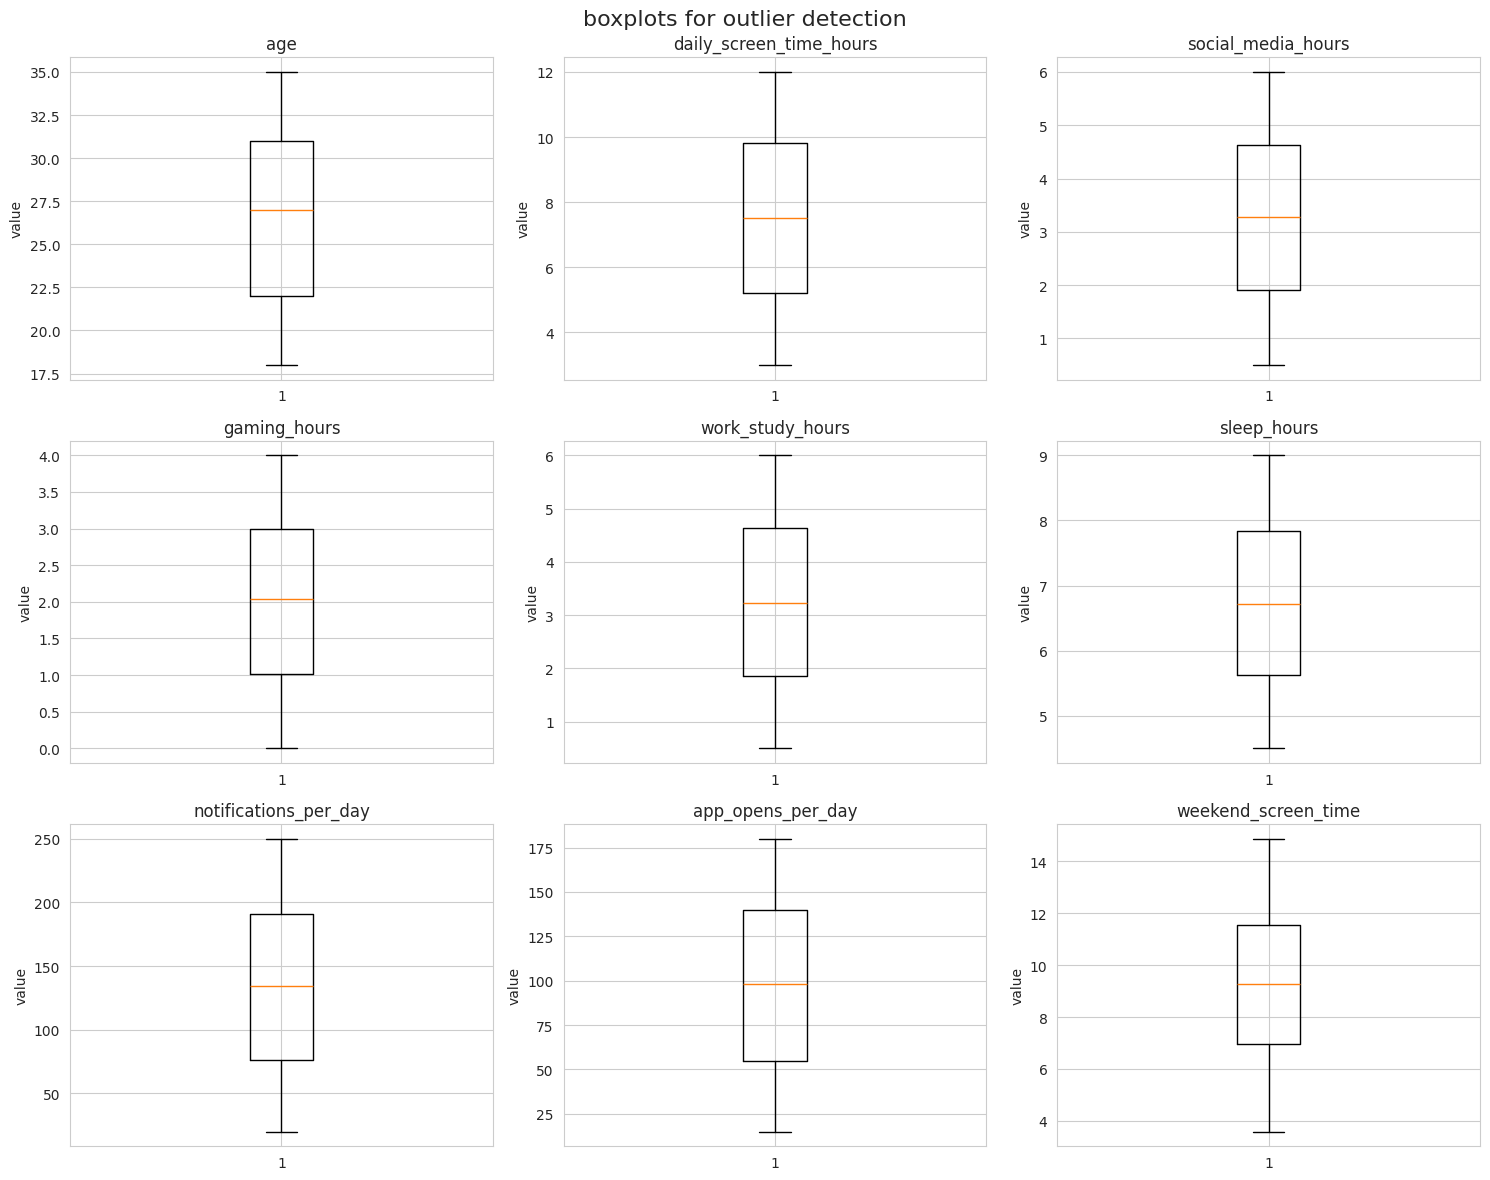

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(num_cols):
    axes[idx].boxplot(df[col])
    axes[idx].set_title(f'{col}')
    axes[idx].set_ylabel('value')
plt.suptitle('boxplots for outlier detection', fontsize=16)
plt.tight_layout()
plt.show()

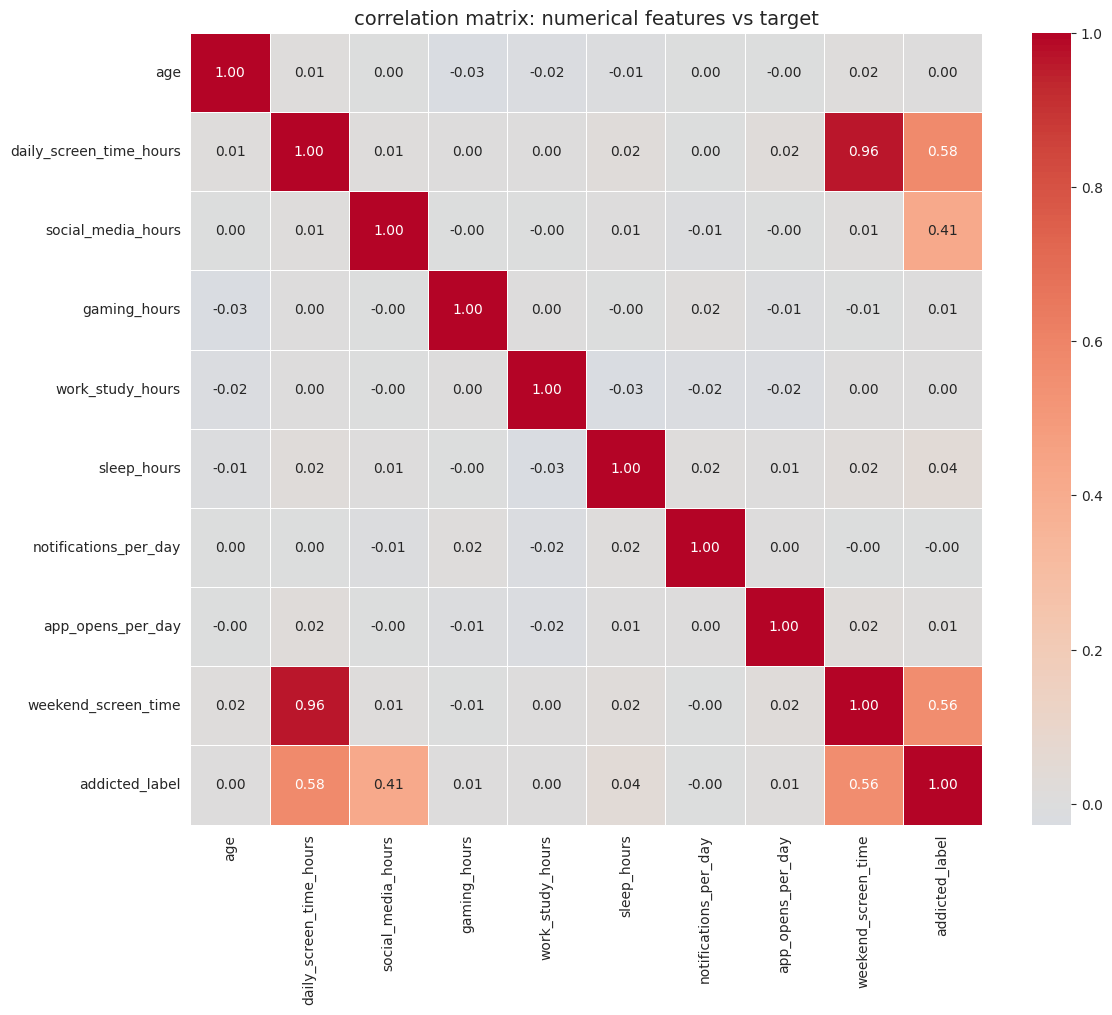

In [9]:
plt.figure(figsize=(12, 10))
correlation_matrix = df[num_cols + ['addicted_label']].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('correlation matrix: numerical features vs target', fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# top correlations with target
print("top correlations with addiction label")
target_corr = correlation_matrix['addicted_label'].sort_values(ascending=False)
for feature, corr in target_corr.items():
    if feature != 'addicted_label':
        strength = "strong" if abs(corr) > 0.5 else "moderate" if abs(corr) > 0.3 else "weak"
        direction = "positive" if corr > 0 else "negative"
        print(f"{feature:25s}: {corr:7.3f} ({strength} {direction})")

top correlations with addiction label
daily_screen_time_hours  :   0.577 (strong positive)
weekend_screen_time      :   0.555 (strong positive)
social_media_hours       :   0.414 (moderate positive)
sleep_hours              :   0.035 (weak positive)
app_opens_per_day        :   0.011 (weak positive)
gaming_hours             :   0.008 (weak positive)
age                      :   0.004 (weak positive)
work_study_hours         :   0.001 (weak positive)
notifications_per_day    :  -0.001 (weak negative)


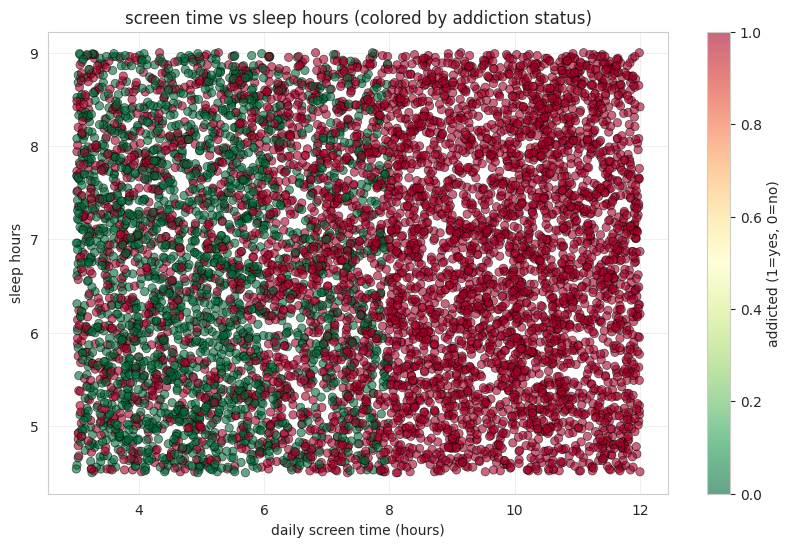

In [11]:
# screen time vs sleep colored by addiction
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['daily_screen_time_hours'], df['sleep_hours'], 
                      c=df['addicted_label'], cmap='RdYlGn_r', alpha=0.6, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, label='addicted (1=yes, 0=no)')
plt.xlabel('daily screen time (hours)')
plt.ylabel('sleep hours')
plt.title('screen time vs sleep hours (colored by addiction status)')
plt.grid(True, alpha=0.3)
plt.show()

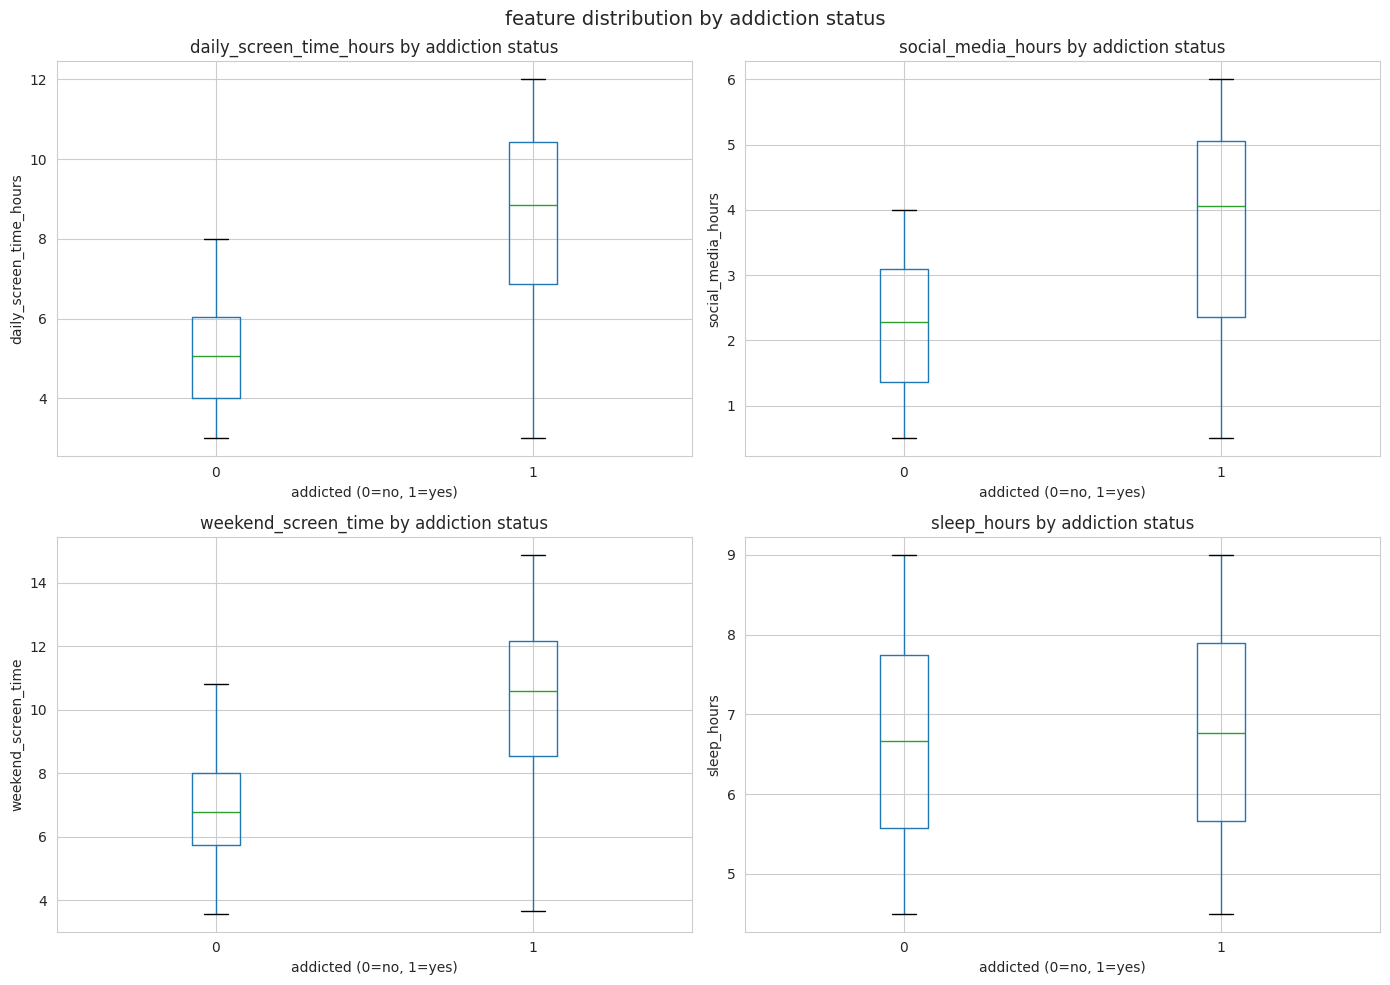

In [12]:
# compare features across addiction groups
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
features = ['daily_screen_time_hours', 'social_media_hours', 'weekend_screen_time', 'sleep_hours']

for idx, feature in enumerate(features):
    row, col = idx // 2, idx % 2
    df.boxplot(column=feature, by='addicted_label', ax=axes[row, col])
    axes[row, col].set_title(f'{feature} by addiction status')
    axes[row, col].set_xlabel('addicted (0=no, 1=yes)')
    axes[row, col].set_ylabel(feature)
plt.suptitle('feature distribution by addiction status', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
# statistical differences between groups
print("statistical differences between addicted vs non addicted")
for feature in num_cols:
    non_addicted = df[df['addicted_label'] == 0][feature]
    addicted = df[df['addicted_label'] == 1][feature]
    diff_pct = ((addicted.mean() - non_addicted.mean()) / non_addicted.mean()) * 100
    print(f"{feature:25s}: non-addicted={non_addicted.mean():7.2f} | addicted={addicted.mean():7.2f} | diff={diff_pct:+.1f}%")


statistical differences between addicted vs non addicted
age                      : non-addicted=  26.53 | addicted=  26.58 | diff=+0.2%
daily_screen_time_hours  : non-addicted=   5.16 | addicted=   8.47 | diff=+64.2%
social_media_hours       : non-addicted=   2.25 | addicted=   3.70 | diff=+64.1%
gaming_hours             : non-addicted=   2.00 | addicted=   2.02 | diff=+1.1%
work_study_hours         : non-addicted=   3.24 | addicted=   3.24 | diff=+0.1%
sleep_hours              : non-addicted=   6.67 | addicted=   6.77 | diff=+1.5%
notifications_per_day    : non-addicted= 134.33 | addicted= 134.23 | diff=-0.1%
app_opens_per_day        : non-addicted=  97.00 | addicted=  98.18 | diff=+1.2%
weekend_screen_time      : non-addicted=   6.89 | addicted=  10.21 | diff=+48.1%


In [15]:
# check sleep deficit (corrected interpretation)
df['sleep_deficit'] = 8 - df['sleep_hours']
new_corr = df[['daily_screen_time_hours', 'sleep_deficit', 'addicted_label']].corr()
print("\ncorrected correlation with sleep_deficit:")
print(f"screen time vs sleep_deficit: {new_corr.loc['daily_screen_time_hours', 'sleep_deficit']:.3f}")
print(f"sleep_deficit vs addiction: {new_corr.loc['sleep_deficit', 'addicted_label']:.3f}")


corrected correlation with sleep_deficit:
screen time vs sleep_deficit: -0.019
sleep_deficit vs addiction: -0.035


In [16]:
# feature engineering
df_clean = df.copy()
df_clean["total_screen_time"] = df_clean["daily_screen_time_hours"] + df_clean["weekend_screen_time"]
df_clean["digital_intensity"] = df_clean["notifications_per_day"] + df_clean["app_opens_per_day"]
df_clean["social_ratio"] = df_clean["social_media_hours"] / (df_clean["daily_screen_time_hours"] + 1e-6)
df_clean["sleep_deficit"] = 8 - df_clean["sleep_hours"]
df_clean["entertainment_load"] = df_clean["social_media_hours"] + df_clean["gaming_hours"]

In [17]:
# encode categorical variables
df_clean["stress_level"] = df_clean["stress_level"].map({"Low": 0, "Medium": 1, "High": 2})
df_clean = pd.get_dummies(df_clean, columns=["gender"], drop_first=True)
df_clean["academic_work_impact"] = df_clean["academic_work_impact"].map({"No": 0, "Yes": 1})

In [18]:
# drop the original ordinal addiction_level (we'll use binary label)
df_clean = df_clean.drop(columns=["addiction_level"])

print(f"cleaned dataset shape: {df_clean.shape}")
print(f"\nnew features created: total_screen_time, digital_intensity, social_ratio, sleep_deficit, entertainment_load")
print(f"\ncolumns after engineering:\n{df_clean.columns.tolist()}")

cleaned dataset shape: (7500, 19)

new features created: total_screen_time, digital_intensity, social_ratio, sleep_deficit, entertainment_load

columns after engineering:
['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact', 'addicted_label', 'sleep_deficit', 'total_screen_time', 'digital_intensity', 'social_ratio', 'entertainment_load', 'gender_Male', 'gender_Other']


In [19]:
# prepare data for modeling
X_full = df_clean.drop(columns=["addicted_label"])
y = df_clean["addicted_label"]
scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(X_full)

# prepare 2-feature dataset (top 2 from correlation analysis)
X_simple = df_clean[['daily_screen_time_hours', 'social_media_hours']]

# scale the simple data
scaler_simple = StandardScaler()
X_simple_scaled = scaler_simple.fit_transform(X_simple)

print(f"full features: {X_full.shape[1]} features")
print(f"simplified features: {X_simple.shape[1]} features")
print(f"total samples: {len(y)}")
print(f"\ntarget distribution:\n{y.value_counts(normalize=True)}")

full features: 18 features
simplified features: 2 features
total samples: 7500

target distribution:
addicted_label
1    0.707733
0    0.292267
Name: proportion, dtype: float64


In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# define models with appropriate scaling needs
models = {
    "logistic regression (scaled)": LogisticRegression(class_weight="balanced", max_iter=1000),
    "svm rbf (scaled)": SVC(probability=True, class_weight="balanced", random_state=42),
    "knn (scaled)": KNeighborsClassifier(),
    "random forest (no scaling)": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
    "gradient boosting (no scaling)": GradientBoostingClassifier(random_state=42),
}

In [22]:
# scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score),
    'roc_auc': 'roc_auc'
}

In [23]:
# compare models on full features (18 features)
print("model comparison: full features (18 features)")
print("=" * 80)

full_results = []

for name, model in models.items():
    if "scaled" in name:
        X_data = X_full_scaled
    else:
        X_data = X_full
    cv_scores = cross_validate(model, X_data, y, cv=cv, scoring=scoring, return_train_score=False)
    
    full_results.append({
        "model": name,
        "cv_accuracy_mean": cv_scores['test_accuracy'].mean(),
        "cv_accuracy_std": cv_scores['test_accuracy'].std(),
        "cv_f1_mean": cv_scores['test_f1'].mean(),
        "cv_f1_std": cv_scores['test_f1'].std(),
        "cv_auc_mean": cv_scores['test_roc_auc'].mean(),
        "cv_auc_std": cv_scores['test_roc_auc'].std()
    })
    
    print(f"\n{name}")
    print(f"  accuracy: {cv_scores['test_accuracy'].mean():.4f} (+/-{cv_scores['test_accuracy'].std():.4f})")
    print(f"  f1 score: {cv_scores['test_f1'].mean():.4f} (+/-{cv_scores['test_f1'].std():.4f})")
    print(f"  roc-auc:  {cv_scores['test_roc_auc'].mean():.4f} (+/-{cv_scores['test_roc_auc'].std():.4f})")

# create results dataframe
full_results_df = pd.DataFrame(full_results)
print("\n" + "=" * 80)
print("summary - full features (18 features)")
print("=" * 80)
print(full_results_df.sort_values('cv_auc_mean', ascending=False).round(4).to_string(index=False))

model comparison: full features (18 features)

logistic regression (scaled)
  accuracy: 0.9101 (+/-0.0040)
  f1 score: 0.9345 (+/-0.0030)
  roc-auc:  0.9741 (+/-0.0021)

svm rbf (scaled)
  accuracy: 0.9173 (+/-0.0045)
  f1 score: 0.9396 (+/-0.0035)
  roc-auc:  0.9774 (+/-0.0017)

knn (scaled)
  accuracy: 0.8912 (+/-0.0062)
  f1 score: 0.9241 (+/-0.0045)
  roc-auc:  0.9416 (+/-0.0021)

random forest (no scaling)
  accuracy: 0.9344 (+/-0.0062)
  f1 score: 0.9535 (+/-0.0045)
  roc-auc:  0.9891 (+/-0.0012)

gradient boosting (no scaling)
  accuracy: 0.9357 (+/-0.0032)
  f1 score: 0.9542 (+/-0.0023)
  roc-auc:  0.9891 (+/-0.0006)

summary - full features (18 features)
                         model  cv_accuracy_mean  cv_accuracy_std  cv_f1_mean  cv_f1_std  cv_auc_mean  cv_auc_std
    random forest (no scaling)            0.9344           0.0062      0.9535     0.0045       0.9891      0.0012
gradient boosting (no scaling)            0.9357           0.0032      0.9542     0.0023       0.989

best model (based on cv auc): random forest (no scaling)

top 10 most important features:
daily_screen_time_hours    0.2544
social_media_hours         0.2474
total_screen_time          0.1704
weekend_screen_time        0.1127
entertainment_load         0.0634
social_ratio               0.0588
gaming_hours               0.0172
work_study_hours           0.0109
digital_intensity          0.0103
notifications_per_day      0.0103
dtype: float64


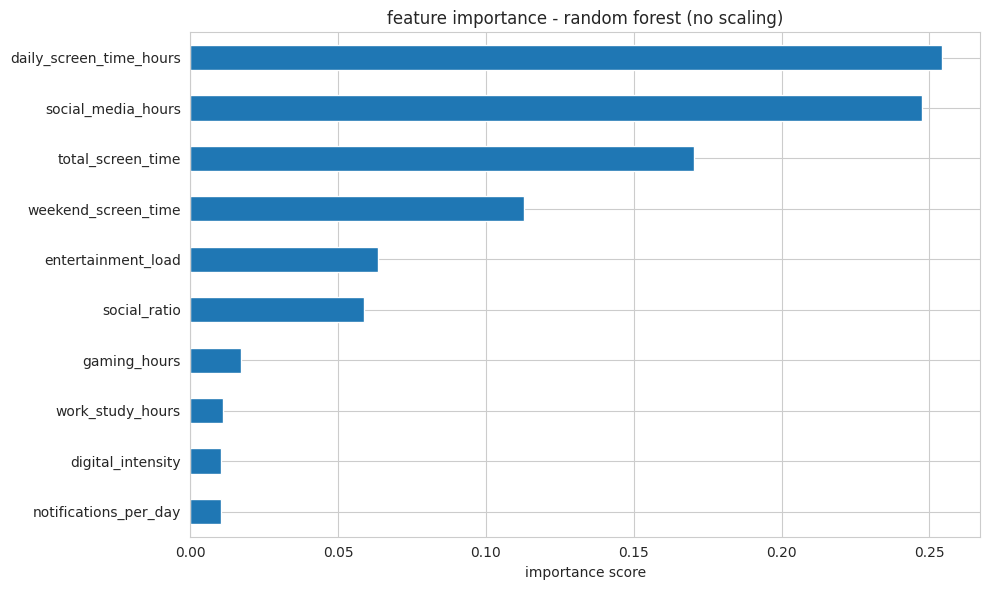


top 2 features identified: ['daily_screen_time_hours', 'social_media_hours']


In [24]:
# find best model from cv results
best_model_name = full_results_df.loc[full_results_df['cv_auc_mean'].idxmax(), 'model']
print(f"best model (based on cv auc): {best_model_name}")
print("=" * 80)

# train best model on all data for feature importance
if "gradient boosting" in best_model_name:
    best_model = GradientBoostingClassifier(random_state=42)
    best_model.fit(X_full, y)
elif "random forest" in best_model_name:
    best_model = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
    best_model.fit(X_full, y)
elif "svm" in best_model_name:
    best_model = SVC(probability=True, class_weight="balanced", random_state=42)
    best_model.fit(X_full_scaled, y)
else:
    best_model = LogisticRegression(class_weight="balanced", max_iter=1000)
    best_model.fit(X_full_scaled, y)

# feature importance for tree-based models
if hasattr(best_model, 'feature_importances_'):
    importance = pd.Series(best_model.feature_importances_, index=X_full.columns).sort_values(ascending=False)
    
    print("\ntop 10 most important features:")
    print(importance.head(10).round(4))
    
    plt.figure(figsize=(10, 6))
    importance.head(10).plot(kind='barh')
    plt.title(f'feature importance - {best_model_name}')
    plt.xlabel('importance score')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    # identify top 2 features
    top_2_features = importance.head(2).index.tolist()
    print(f"\ntop 2 features identified: {top_2_features}")
else:
    print("model doesn't have feature importance attribute")
    print("using pre-identified top 2 features: daily_screen_time_hours, social_media_hours")
    top_2_features = ['daily_screen_time_hours', 'social_media_hours']

In [25]:
# simplified models with 2 features
print("simplified models (2 features) - cross-validation only")
print("=" * 80)

simplified_models = {
    "logistic regression (2f, scaled)": LogisticRegression(class_weight="balanced", max_iter=1000),
    "svm rbf (2f, scaled)": SVC(probability=True, class_weight="balanced", random_state=42),
    "knn (2f, scaled)": KNeighborsClassifier(),
    "random forest (2f, no scaling)": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
    "gradient boosting (2f, no scaling)": GradientBoostingClassifier(random_state=42),
}

simple_results = []

for name, model in simplified_models.items():
    
    if "scaled" in name:
        X_data = X_simple_scaled
    else:
        X_data = X_simple
    
    
    cv_scores = cross_validate(model, X_data, y, cv=cv, scoring=scoring, return_train_score=False)
    
    simple_results.append({
        "model": name,
        "cv_accuracy_mean": cv_scores['test_accuracy'].mean(),
        "cv_accuracy_std": cv_scores['test_accuracy'].std(),
        "cv_f1_mean": cv_scores['test_f1'].mean(),
        "cv_f1_std": cv_scores['test_f1'].std(),
        "cv_auc_mean": cv_scores['test_roc_auc'].mean(),
        "cv_auc_std": cv_scores['test_roc_auc'].std()
    })
    
    print(f"\n{name}")
    print(f"  accuracy: {cv_scores['test_accuracy'].mean():.4f} (+/-{cv_scores['test_accuracy'].std():.4f})")
    print(f"  f1 score: {cv_scores['test_f1'].mean():.4f} (+/-{cv_scores['test_f1'].std():.4f})")
    print(f"  roc-auc:  {cv_scores['test_roc_auc'].mean():.4f} (+/-{cv_scores['test_roc_auc'].std():.4f})")

simple_results_df = pd.DataFrame(simple_results)
print("\n" + "=" * 80)
print("summary - simplified models (2 features)")
print("=" * 80)
print(simple_results_df.sort_values('cv_auc_mean', ascending=False).round(4).to_string(index=False))

simplified models (2 features) - cross-validation only

logistic regression (2f, scaled)
  accuracy: 0.8671 (+/-0.0066)
  f1 score: 0.9016 (+/-0.0050)
  roc-auc:  0.9531 (+/-0.0027)

svm rbf (2f, scaled)
  accuracy: 0.9285 (+/-0.0046)
  f1 score: 0.9472 (+/-0.0035)
  roc-auc:  0.9747 (+/-0.0022)

knn (2f, scaled)
  accuracy: 0.9279 (+/-0.0043)
  f1 score: 0.9489 (+/-0.0033)
  roc-auc:  0.9823 (+/-0.0022)

random forest (2f, no scaling)
  accuracy: 0.9307 (+/-0.0062)
  f1 score: 0.9510 (+/-0.0044)
  roc-auc:  0.9887 (+/-0.0008)

gradient boosting (2f, no scaling)
  accuracy: 0.9363 (+/-0.0027)
  f1 score: 0.9543 (+/-0.0019)
  roc-auc:  0.9892 (+/-0.0002)

summary - simplified models (2 features)
                             model  cv_accuracy_mean  cv_accuracy_std  cv_f1_mean  cv_f1_std  cv_auc_mean  cv_auc_std
gradient boosting (2f, no scaling)            0.9363           0.0027      0.9543     0.0019       0.9892      0.0002
    random forest (2f, no scaling)            0.9307        

In [26]:
# cell 16: compare full vs simplified models
print("comparison: full features (18) vs simplified (2 features)")
print("=" * 80)

# get best models
best_full = full_results_df.loc[full_results_df['cv_auc_mean'].idxmax()]
best_simple = simple_results_df.loc[simple_results_df['cv_auc_mean'].idxmax()]

comparison = pd.DataFrame({
    'metric': ['cv auc mean', 'cv auc std', 'cv f1 mean', 'cv f1 std', 'cv accuracy mean'],
    'full model (18 features)': [
        best_full['cv_auc_mean'],
        best_full['cv_auc_std'],
        best_full['cv_f1_mean'],
        best_full['cv_f1_std'],
        best_full['cv_accuracy_mean']
    ],
    'simplified (2 features)': [
        best_simple['cv_auc_mean'],
        best_simple['cv_auc_std'],
        best_simple['cv_f1_mean'],
        best_simple['cv_f1_std'],
        best_simple['cv_accuracy_mean']
    ],
    'difference': [
        best_full['cv_auc_mean'] - best_simple['cv_auc_mean'],
        best_simple['cv_auc_std'] - best_full['cv_auc_std'],
        best_full['cv_f1_mean'] - best_simple['cv_f1_mean'],
        best_simple['cv_f1_std'] - best_full['cv_f1_std'],
        best_full['cv_accuracy_mean'] - best_simple['cv_accuracy_mean']
    ]
})

print(f"\nbest full model: {best_full['model']}")
print(f"best simplified model: {best_simple['model']}")
print("\n" + "=" * 80)
print(comparison.round(4).to_string(index=False))

print("\n" + "=" * 80)
print("performance loss summary")
print("=" * 80)
auc_loss = best_full['cv_auc_mean'] - best_simple['cv_auc_mean']
stability_gain = best_full['cv_auc_std'] - best_simple['cv_auc_std']

print(f"auc loss: {auc_loss:.4f} ({auc_loss*100:.2f}%)")
print(f"stability improvement: {stability_gain:.4f} (lower std is better)")

comparison: full features (18) vs simplified (2 features)

best full model: random forest (no scaling)
best simplified model: gradient boosting (2f, no scaling)

          metric  full model (18 features)  simplified (2 features)  difference
     cv auc mean                    0.9891                   0.9892     -0.0000
      cv auc std                    0.0012                   0.0002     -0.0010
      cv f1 mean                    0.9535                   0.9543     -0.0008
       cv f1 std                    0.0045                   0.0019     -0.0025
cv accuracy mean                    0.9344                   0.9363     -0.0019

performance loss summary
auc loss: -0.0000 (-0.00%)
stability improvement: 0.0010 (lower std is better)


comprehensive visualization - best model: gradient boosting (2 features)


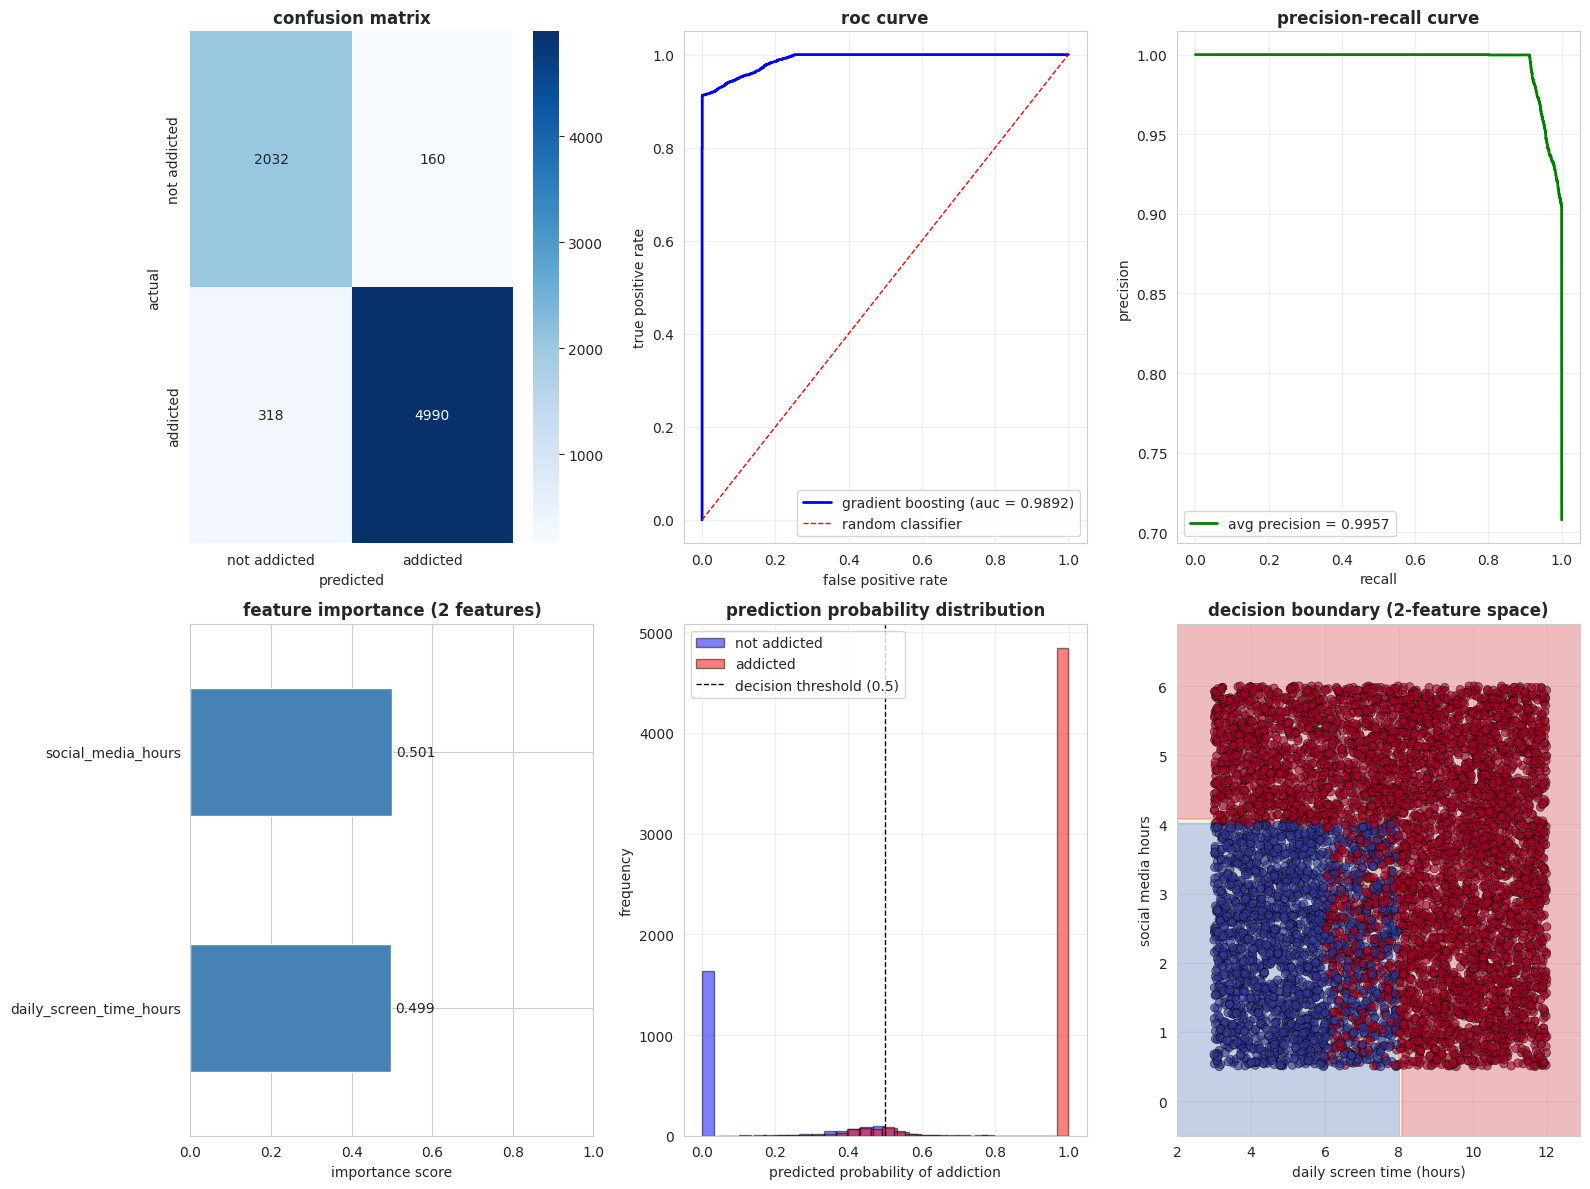


best model performance summary (gradient boosting - 2 features)


NameError: name 'cv_accuracy' is not defined

In [27]:
# cell 19: comprehensive visualization of best model results
print("comprehensive visualization - best model: gradient boosting (2 features)")
print("=" * 80)

# get predictions from the best model
best_model = GradientBoostingClassifier(random_state=42)
best_model.fit(X_simple, y)

# get cross-validated predictions
y_pred_cv = cross_val_predict(best_model, X_simple, y, cv=cv, method='predict')
y_proba_cv = cross_val_predict(best_model, X_simple, y, cv=cv, method='predict_proba')[:, 1]

# create a figure with subplots
fig = plt.figure(figsize=(16, 12))

# 1. confusion matrix
ax1 = plt.subplot(2, 3, 1)
cm = confusion_matrix(y, y_pred_cv)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['not addicted', 'addicted'],
            yticklabels=['not addicted', 'addicted'],
            ax=ax1)
ax1.set_title('confusion matrix', fontsize=12, fontweight='bold')
ax1.set_ylabel('actual')
ax1.set_xlabel('predicted')

# 2. roc curve
ax2 = plt.subplot(2, 3, 2)
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y, y_proba_cv)
auc_score = roc_auc_score(y, y_proba_cv)
ax2.plot(fpr, tpr, 'b-', linewidth=2, label=f'gradient boosting (auc = {auc_score:.4f})')
ax2.plot([0, 1], [0, 1], 'r--', linewidth=1, label='random classifier')
ax2.set_xlabel('false positive rate')
ax2.set_ylabel('true positive rate')
ax2.set_title('roc curve', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

# 3. precision-recall curve
ax3 = plt.subplot(2, 3, 3)
from sklearn.metrics import precision_recall_curve, average_precision_score
precision, recall, _ = precision_recall_curve(y, y_proba_cv)
avg_precision = average_precision_score(y, y_proba_cv)
ax3.plot(recall, precision, 'g-', linewidth=2, label=f'avg precision = {avg_precision:.4f}')
ax3.set_xlabel('recall')
ax3.set_ylabel('precision')
ax3.set_title('precision-recall curve', fontsize=12, fontweight='bold')
ax3.legend(loc='lower left')
ax3.grid(True, alpha=0.3)

# 4. feature importance (for the 2 features)
ax4 = plt.subplot(2, 3, 4)
if hasattr(best_model, 'feature_importances_'):
    importance = pd.Series(best_model.feature_importances_, index=['daily_screen_time_hours', 'social_media_hours'])
    importance.plot(kind='barh', ax=ax4, color='steelblue')
    ax4.set_xlabel('importance score')
    ax4.set_title('feature importance (2 features)', fontsize=12, fontweight='bold')
    ax4.set_xlim(0, 1)
    for i, v in enumerate(importance.values):
        ax4.text(v + 0.01, i, f'{v:.3f}', va='center')

# 5. prediction probability distribution
ax5 = plt.subplot(2, 3, 5)
ax5.hist(y_proba_cv[y==0], bins=30, alpha=0.5, label='not addicted', color='blue', edgecolor='black')
ax5.hist(y_proba_cv[y==1], bins=30, alpha=0.5, label='addicted', color='red', edgecolor='black')
ax5.axvline(x=0.5, color='black', linestyle='--', linewidth=1, label='decision threshold (0.5)')
ax5.set_xlabel('predicted probability of addiction')
ax5.set_ylabel('frequency')
ax5.set_title('prediction probability distribution', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. decision boundary (scatter plot of predictions)
ax6 = plt.subplot(2, 3, 6)

# create a mesh grid for decision boundary
x_min, x_max = X_simple['daily_screen_time_hours'].min() - 1, X_simple['daily_screen_time_hours'].max() + 1
y_min, y_max = X_simple['social_media_hours'].min() - 1, X_simple['social_media_hours'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# predict on mesh grid
Z = best_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# plot decision boundary and points
ax6.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu_r')
scatter = ax6.scatter(X_simple['daily_screen_time_hours'], X_simple['social_media_hours'], 
                      c=y, cmap='RdYlBu_r', edgecolors='black', linewidth=0.5, alpha=0.6)
ax6.set_xlabel('daily screen time (hours)')
ax6.set_ylabel('social media hours')
ax6.set_title('decision boundary (2-feature space)', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# print summary metrics
print("\n" + "=" * 80)
print("best model performance summary (gradient boosting - 2 features)")
print("=" * 80)
print(f"accuracy:  {cv_accuracy:.4f}")
print(f"f1 score:  {cv_f1:.4f}")
print(f"roc-auc:   {cv_auc:.4f}")
print(f"avg precision: {avg_precision:.4f}")
print("\nclassification by feature importance:")
print(f"  daily screen time: {importance['daily_screen_time_hours']:.3f}")
print(f"  social media hours: {importance['social_media_hours']:.3f}")

generating synthetic data to test model predictions

synthetic data summary:
total synthetic samples: 100

prediction distribution:
predicted_addiction
1    0.76
0    0.24
Name: proportion, dtype: float64

probability statistics:
count    100.0000
mean       0.7731
std        0.4041
min        0.0009
25%        0.8794
50%        0.9990
75%        0.9992
max        0.9996
Name: addiction_probability, dtype: float64


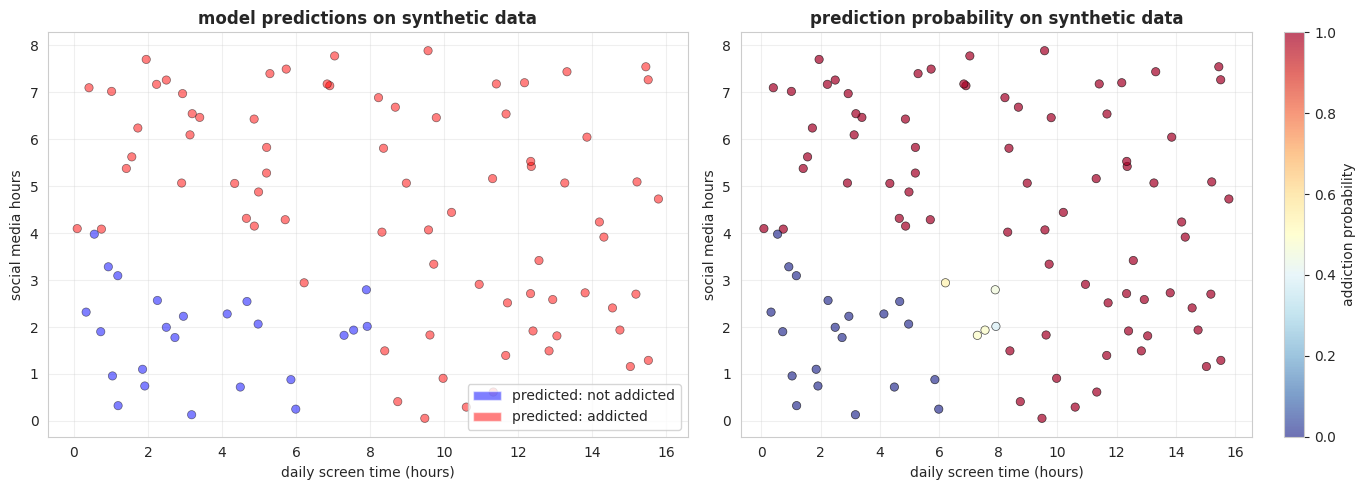


random sample of 20 synthetic cases (actual model predictions):
 daily_screen_time_hours  social_media_hours  addiction_probability  predicted_addiction
                    1.02                7.02                   1.00                    1
                    2.50                7.26                   1.00                    1
                   12.34                5.53                   1.00                    1
                   12.36                5.42                   1.00                    1
                   13.32                7.44                   1.00                    1
                   10.60                0.30                   1.00                    1
                   15.18                2.70                   1.00                    1
                   13.81                2.73                   1.00                    1
                   13.05                1.81                   1.00                    1
                   14.32                3.92 

In [28]:
# cell 20: generate synthetic data to test model predictions
print("generating synthetic data to test model predictions")
print("=" * 80)

# create synthetic test cases covering realistic usage patterns
np.random.seed(42)
n_synthetic = 100

# generate realistic ranges
daily_screen_time = np.random.uniform(0, 16, n_synthetic)  # 0-16 hours
social_media_hours = np.random.uniform(0, 8, n_synthetic)  # 0-8 hours

synthetic_data = pd.DataFrame({
    'daily_screen_time_hours': daily_screen_time,
    'social_media_hours': social_media_hours
})

# get model predictions
synthetic_data['predicted_addiction'] = best_model.predict(synthetic_data[['daily_screen_time_hours', 'social_media_hours']])
synthetic_data['addiction_probability'] = best_model.predict_proba(synthetic_data[['daily_screen_time_hours', 'social_media_hours']])[:, 1]

# show summary statistics
print("\nsynthetic data summary:")
print("=" * 80)
print(f"total synthetic samples: {len(synthetic_data)}")
print(f"\nprediction distribution:")
print(synthetic_data['predicted_addiction'].value_counts(normalize=True).round(3))
print(f"\nprobability statistics:")
print(synthetic_data['addiction_probability'].describe().round(4))

# visualize synthetic predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# plot 1: predictions colored by model output
ax1 = axes[0]
colors = ['blue' if x == 0 else 'red' for x in synthetic_data['predicted_addiction']]
scatter1 = ax1.scatter(synthetic_data['daily_screen_time_hours'], 
                       synthetic_data['social_media_hours'],
                       c=colors, alpha=0.5, edgecolors='black', linewidth=0.5)
ax1.set_xlabel('daily screen time (hours)')
ax1.set_ylabel('social media hours')
ax1.set_title('model predictions on synthetic data', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# add color legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', alpha=0.5, label='predicted: not addicted'),
                   Patch(facecolor='red', alpha=0.5, label='predicted: addicted')]
ax1.legend(handles=legend_elements)

# plot 2: probability heatmap
ax2 = axes[1]
scatter2 = ax2.scatter(synthetic_data['daily_screen_time_hours'], 
                       synthetic_data['social_media_hours'],
                       c=synthetic_data['addiction_probability'], 
                       cmap='RdYlBu_r', alpha=0.7, edgecolors='black', linewidth=0.5,
                       vmin=0, vmax=1)
plt.colorbar(scatter2, ax=ax2, label='addiction probability')
ax2.set_xlabel('daily screen time (hours)')
ax2.set_ylabel('social media hours')
ax2.set_title('prediction probability on synthetic data', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# show 20 random samples to see individual predictions
print("\n" + "=" * 80)
print("random sample of 20 synthetic cases (actual model predictions):")
print("=" * 80)
sample = synthetic_data.sample(20, random_state=42).sort_values('addiction_probability', ascending=False)
sample_display = sample.copy()
sample_display['addiction_probability'] = sample_display['addiction_probability'].round(3)
print(sample_display[['daily_screen_time_hours', 'social_media_hours', 
                      'addiction_probability', 'predicted_addiction']].round(2).to_string(index=False))